# Transcript Visualizations

This notebook visualizes the local transcript corpus using aggregate statistics only: volume over time, length distributions, top terms, keyword themes, finance-related language, and topic co-occurrence.


## Setup

Parse transcript titles, dates, and bodies from the local `transcripts/` folder. The raw text is not printed; the notebook works with aggregate features.


In [1]:
from pathlib import Path
from collections import Counter
import calendar
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

TRANSCRIPT_DIR = Path("../transcripts")
ASSET_PATH = Path("assets/transcript_visualizations")
ASSET_PATH.mkdir(parents=True, exist_ok=True)
DELIMITER = "===== TRANSCRIPT BEGIN ====="

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#f7f3ea",
    "axes.facecolor": "#fffaf0",
    "savefig.facecolor": "#f7f3ea",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#d8d0bf",
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

ink = "#272522"
muted = "#6f6a60"
cream = "#f7f3ea"
panel = "#fffaf0"
blue = "#2f6f8f"
gold = "#d79a2b"
red = "#b33f3f"
teal = "#4d9b8f"
plum = "#6e4b7e"
heat_cmap = LinearSegmentedColormap.from_list("transcript_heat", ["#fffaf0", "#f1c66a", "#c76348", "#7f2538"])
blue_cmap = LinearSegmentedColormap.from_list("transcript_blue", ["#fffaf0", "#b8d6d0", "#4d9b8f", "#234b62"])

def polish(ax, title=None, subtitle=None):
    ax.set_facecolor(panel)
    ax.spines["left"].set_color("#c7bea9")
    ax.spines["bottom"].set_color("#c7bea9")
    ax.tick_params(axis="both", length=0, pad=6, colors="#3a3a3a")
    if title:
        ax.set_title(title, loc="left", color=ink, pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", color=muted, fontsize=9.5)

def save_fig(fig, filename):
    fig.savefig(ASSET_PATH / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

stop_words = set('''
a an and are as at be been being but by can could did do does doing for from had has have he her here him his i if in into is it its just me my no not of on or our out she so that the their them there they this to was we were what when where which who will with you your about after all also am any because before between both down each few having how more most other over own same should some such than then these those through too under until very would said says say mr president trump question thank thanks yes yeah okay well going get got go know like think people want one two three four five make much many way right really also us donald does don ll ve re
'''.split())

word_re = re.compile(r"[a-z][a-z']+")

def tokenize(text):
    words = []
    for word in word_re.findall(text.lower()):
        word = word.strip("'")
        if len(word) > 2 and word not in stop_words:
            words.append(word)
    return words

def date_from_filename(path):
    token = path.stem.split("-")[0]
    if re.fullmatch(r"\d{8}", token):
        return pd.to_datetime(token, format="%m%d%Y", errors="coerce")
    return pd.NaT

def date_from_title(title):
    match = re.search(r"(\d{1,2})\.(\d{1,2})\.(\d{2,4})", title)
    if not match:
        return pd.NaT
    m, d, y = match.groups()
    if len(y) == 2:
        y = "20" + y
    return pd.to_datetime(f"{m}/{d}/{y}", errors="coerce")


In [2]:
rows = []
for path in sorted(TRANSCRIPT_DIR.glob("*.txt")):
    text = path.read_text(encoding="utf-8", errors="ignore")
    if DELIMITER in text:
        title, body = text.split(DELIMITER, 1)
    else:
        parts = text.split("\n", 1)
        title = parts[0]
        body = parts[1] if len(parts) > 1 else ""
    title = title.strip()
    body = body.strip()
    tokens = tokenize(body)
    date = date_from_filename(path)
    if pd.isna(date):
        date = date_from_title(title)
    rows.append({
        "file": path.name,
        "title": title,
        "date": date,
        "body_chars": len(body),
        "word_count": len(tokens),
        "unique_words": len(set(tokens)),
        "tokens": tokens,
        "body_lower": body.lower(),
    })

transcripts_df = pd.DataFrame(rows)
transcripts_df["month"] = transcripts_df["date"].dt.to_period("M").dt.to_timestamp()
transcripts_df["week"] = transcripts_df["date"].dt.to_period("W").apply(lambda p: p.start_time if pd.notna(p) else pd.NaT)
transcripts_df["weekday"] = transcripts_df["date"].dt.day_name()
transcripts_df["lexical_diversity"] = transcripts_df["unique_words"] / transcripts_df["word_count"].replace(0, np.nan)
transcripts_df["known_date"] = transcripts_df["date"].notna()

summary = pd.DataFrame({
    "metric": ["Transcript files", "Known-date transcripts", "Date range", "Total words", "Median words", "Mean words"],
    "value": [
        f"{len(transcripts_df):,}",
        f"{transcripts_df['known_date'].sum():,}",
        f"{transcripts_df['date'].min().date()} to {transcripts_df['date'].max().date()}",
        f"{transcripts_df['word_count'].sum():,}",
        f"{transcripts_df['word_count'].median():,.0f}",
        f"{transcripts_df['word_count'].mean():,.0f}",
    ]
})
summary


,metric,value
0,Transcript files,423
1,Known-date transcripts,403
2,Date range,2025-05-24 to 2026-04-29
3,Total words,"825,492"
4,Median words,"1,431"
5,Mean words,"1,952"


## Transcript Volume Over Time

This chart shows how many transcripts appear each month and the total amount of text represented by those transcripts.


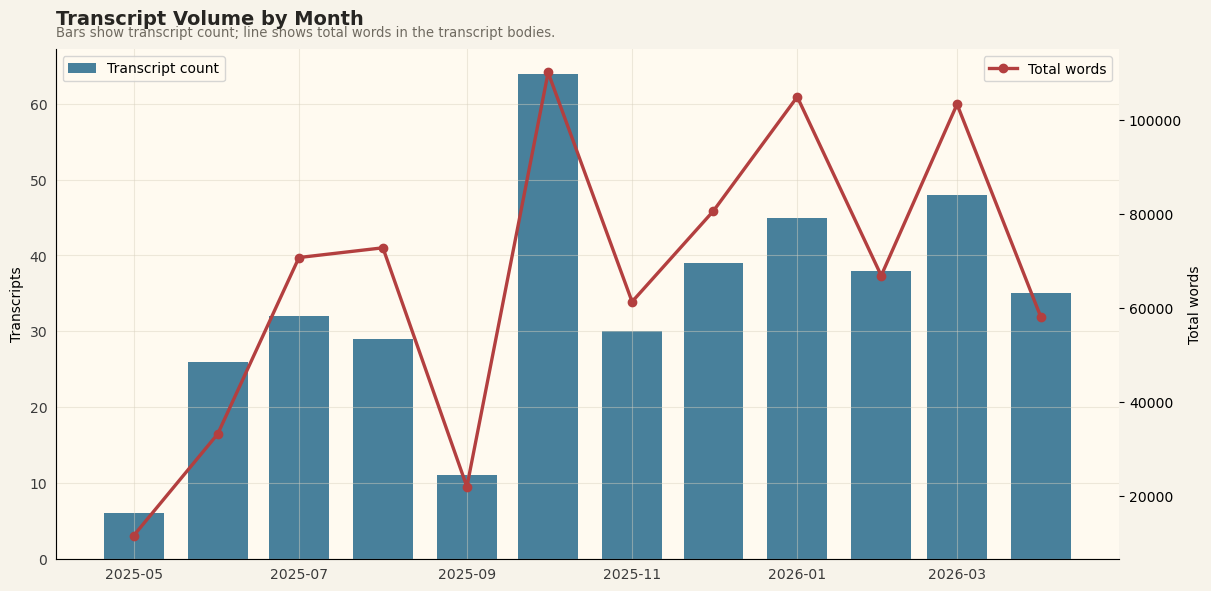

,month,transcript_count,total_words
0,2025-05-01,6,11509
1,2025-06-01,26,33153
2,2025-07-01,32,70738
3,2025-08-01,29,72811
4,2025-09-01,11,21902
5,2025-10-01,64,110165
6,2025-11-01,30,61322
7,2025-12-01,39,80637
8,2026-01-01,45,104975
9,2026-02-01,38,66885


In [3]:
monthly = transcripts_df.dropna(subset=["month"]).groupby("month").agg(
    transcript_count=("file", "count"),
    total_words=("word_count", "sum"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax2 = ax1.twinx()
ax1.bar(monthly["month"], monthly["transcript_count"], width=22, color=blue, alpha=0.88, label="Transcript count")
ax2.plot(monthly["month"], monthly["total_words"], color=red, linewidth=2.4, marker="o", label="Total words")
polish(ax1, "Transcript Volume by Month", "Bars show transcript count; line shows total words in the transcript bodies.")
ax1.set_ylabel("Transcripts")
ax2.set_ylabel("Total words")
ax2.grid(False)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save_fig(fig, "monthly_transcript_volume.png")
plt.show()

monthly.tail(12)


## Transcript Length Distribution

Transcript length is highly uneven, so this view separates short press exchanges from long interviews or speeches.


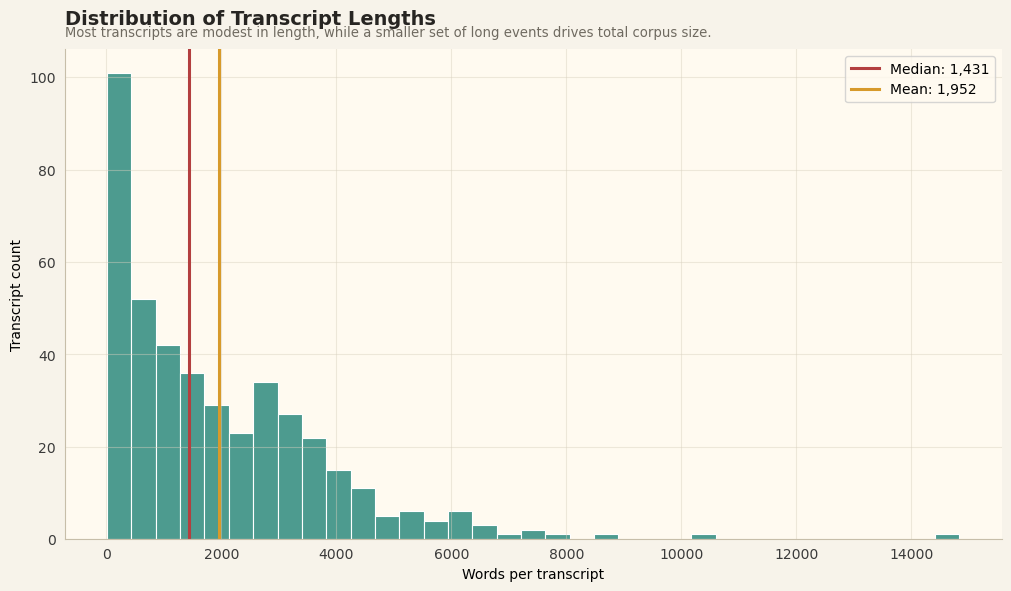

,date,file,word_count,unique_words,lexical_diversity
258,2025-08-26,08262025-0.txt,14829,3162,0.213231
365,2025-12-02,12022025-1.txt,10416,2713,0.260465
4,2026-01-07,01072026-0.txt,8642,2026,0.234436
200,2025-07-08,07082025-0.txt,7972,2184,0.273959
20,2026-01-20,01202026-2.txt,7302,1935,0.264996
282,2025-10-08,10082025-1.txt,7262,2148,0.295786
124,2026-03-26,03262026-2.txt,7100,2023,0.284930
292,2025-10-13,10132025-4.txt,6548,2073,0.316585
7,2026-01-09,01092026-1.txt,6399,1759,0.274887
378,2025-12-09,12092025-1.txt,6389,1641,0.256848


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.hist(transcripts_df["word_count"], bins=35, color=teal, edgecolor="white", linewidth=0.8)
ax.axvline(transcripts_df["word_count"].median(), color=red, linewidth=2.2, label=f"Median: {transcripts_df['word_count'].median():,.0f}")
ax.axvline(transcripts_df["word_count"].mean(), color=gold, linewidth=2.2, label=f"Mean: {transcripts_df['word_count'].mean():,.0f}")
ax.set_xlabel("Words per transcript")
ax.set_ylabel("Transcript count")
polish(ax, "Distribution of Transcript Lengths", "Most transcripts are modest in length, while a smaller set of long events drives total corpus size.")
ax.legend()
save_fig(fig, "transcript_length_distribution.png")
plt.show()

transcripts_df.sort_values("word_count", ascending=False)[["date", "file", "word_count", "unique_words", "lexical_diversity"]].head(10)


## Calendar Heatmap

This heatmap shows transcript activity by month and weekday, helping reveal scheduling patterns in the corpus.


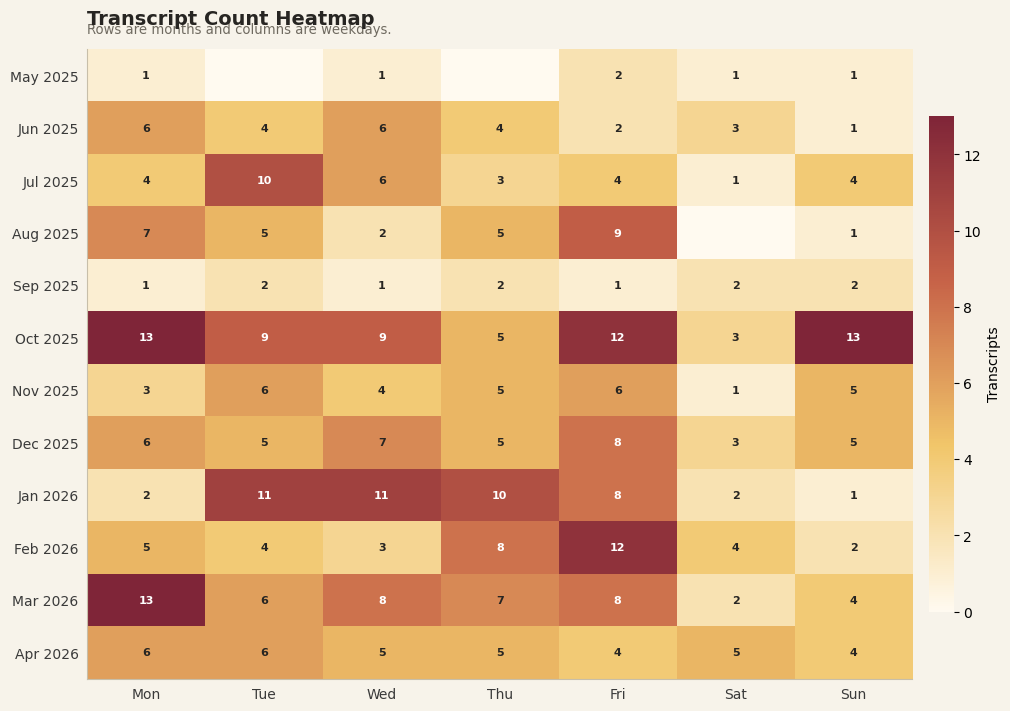

In [5]:
weekday_order = list(calendar.day_name)
calendar_counts = (
    transcripts_df.dropna(subset=["month", "weekday"])
    .pivot_table(index="month", columns="weekday", values="file", aggfunc="count", fill_value=0)
    .reindex(columns=weekday_order)
)
month_labels = [d.strftime("%b %Y") for d in calendar_counts.index]

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
fig.patch.set_facecolor(cream)
im = ax.imshow(calendar_counts.values, aspect="auto", cmap=heat_cmap)
ax.set_xticks(range(len(weekday_order)), [d[:3] for d in weekday_order])
ax.set_yticks(range(len(month_labels)), month_labels)
ax.grid(False)
polish(ax, "Transcript Count Heatmap", "Rows are months and columns are weekdays.")
for i in range(calendar_counts.shape[0]):
    for j in range(calendar_counts.shape[1]):
        val = calendar_counts.iloc[i, j]
        if val:
            ax.text(j, i, str(int(val)), ha="center", va="center", fontsize=8, color="white" if val >= calendar_counts.values.max() * 0.55 else ink, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Transcripts")
cbar.outline.set_visible(False)
save_fig(fig, "calendar_activity_heatmap.png")
plt.show()


## Most Common Terms

After removing basic stop words, the most common terms summarize recurring public-facing themes in the transcript corpus.


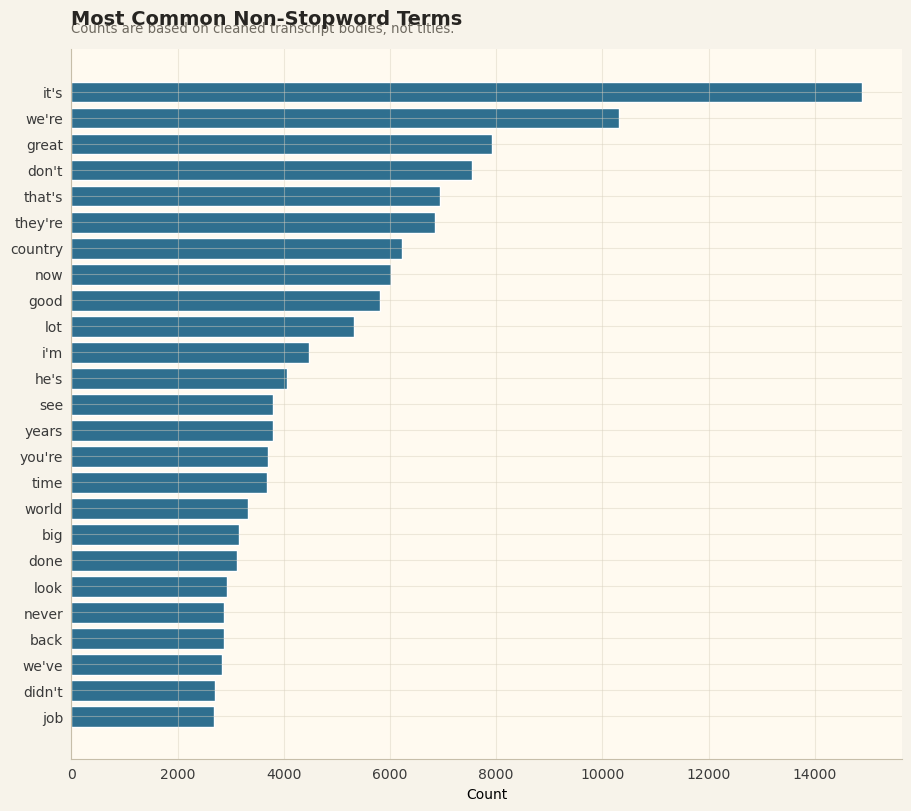

,term,count
0,it's,14892
1,we're,10310
2,great,7915
3,don't,7547
4,that's,6944
5,they're,6839
6,country,6228
7,now,6013
8,good,5814
9,lot,5322


In [6]:
all_tokens = [token for tokens in transcripts_df["tokens"] for token in tokens]
term_counts = Counter(all_tokens)
top_terms = pd.DataFrame(term_counts.most_common(25), columns=["term", "count"]).sort_values("count")

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.barh(top_terms["term"], top_terms["count"], color=blue, edgecolor="white")
ax.set_xlabel("Count")
polish(ax, "Most Common Non-Stopword Terms", "Counts are based on cleaned transcript bodies, not titles.")
save_fig(fig, "top_terms_bar_chart.png")
plt.show()

top_terms.sort_values("count", ascending=False).head(15)


## Common Two-Word Phrases

Bigrams are often easier to interpret than single words because they preserve a little context.


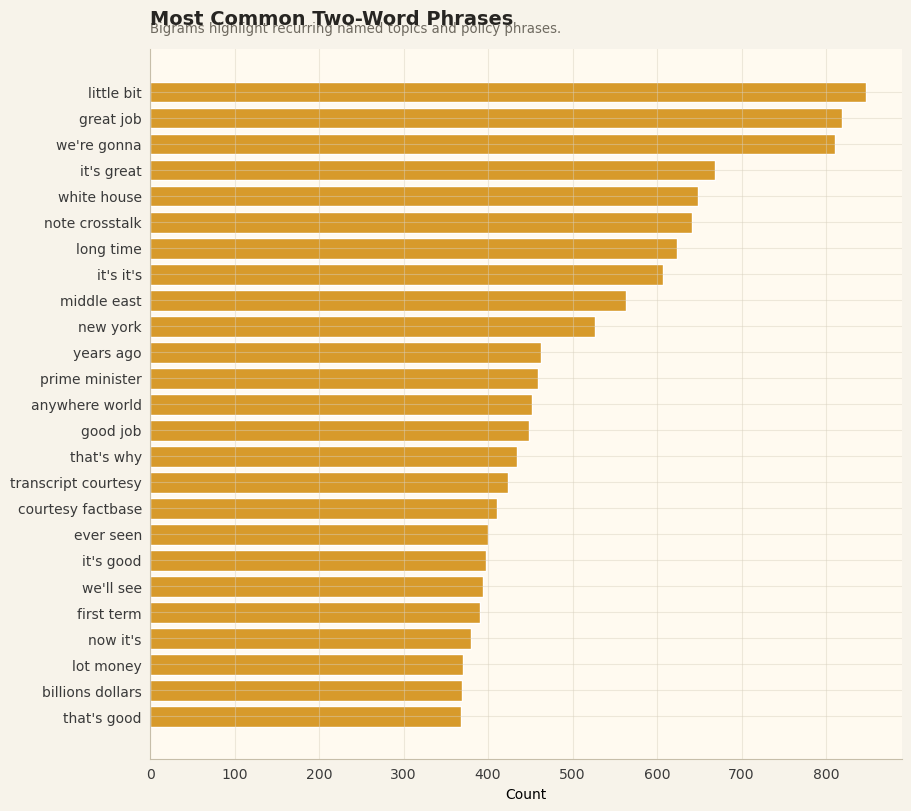

,bigram,count
0,little bit,847
1,great job,819
2,we're gonna,810
3,it's great,668
4,white house,648
5,note crosstalk,641
6,long time,624
7,it's it's,607
8,middle east,563
9,new york,527


In [7]:
bigram_counts = Counter()
for tokens in transcripts_df["tokens"]:
    bigram_counts.update(zip(tokens, tokens[1:]))

banned_bigrams = {("donald", "trump"), ("president", "donald"), ("united", "states")}
bigram_rows = [(f"{a} {b}", count) for (a, b), count in bigram_counts.most_common(100) if (a, b) not in banned_bigrams]
top_bigrams = pd.DataFrame(bigram_rows[:25], columns=["bigram", "count"]).sort_values("count")

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.barh(top_bigrams["bigram"], top_bigrams["count"], color=gold, edgecolor="white")
ax.set_xlabel("Count")
polish(ax, "Most Common Two-Word Phrases", "Bigrams highlight recurring named topics and policy phrases.")
save_fig(fig, "top_bigrams_bar_chart.png")
plt.show()

top_bigrams.sort_values("count", ascending=False).head(15)


## Keyword Theme Prevalence

This view groups hand-built keyword sets into broad themes and measures how often each theme appears in transcripts.


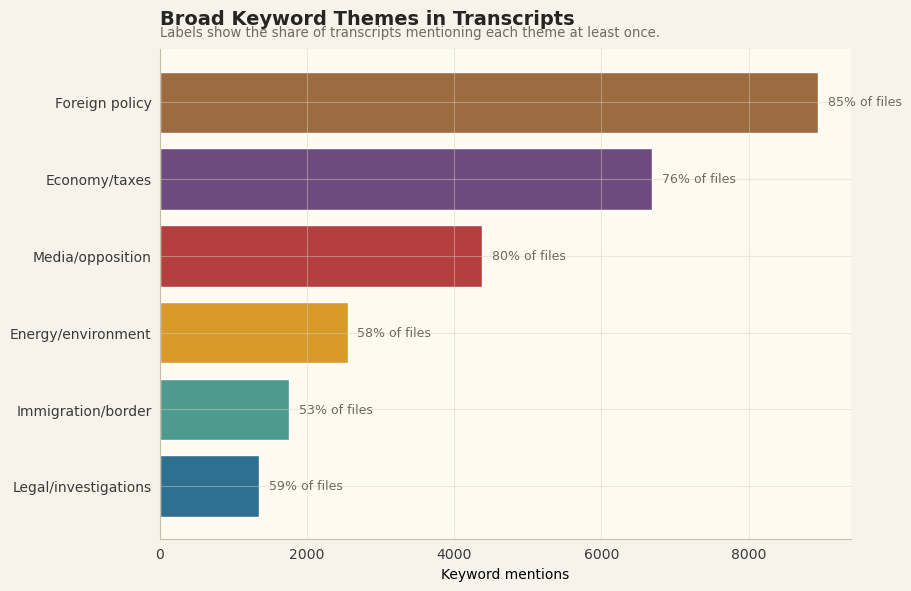

,keyword_mentions,share_of_transcripts
Foreign policy,8942,0.851064
Economy/taxes,6692,0.763593
Media/opposition,4377,0.801418
Energy/environment,2549,0.579196
Immigration/border,1750,0.534279
Legal/investigations,1350,0.593381


In [8]:
theme_keywords = {
    "Economy/taxes": ["economy", "economic", "tax", "taxes", "tariff", "tariffs", "trade", "jobs", "inflation", "prices", "market", "markets"],
    "Immigration/border": ["border", "immigration", "migrant", "migrants", "asylum", "deport", "deported", "ice", "wall"],
    "Foreign policy": ["ukraine", "russia", "putin", "zelensky", "china", "israel", "iran", "nato", "war", "peace", "hostages"],
    "Energy/environment": ["energy", "oil", "gas", "coal", "electric", "climate", "environment", "wind", "solar"],
    "Legal/investigations": ["court", "judge", "legal", "case", "trial", "indictment", "investigation", "justice", "fbi"],
    "Media/opposition": ["media", "press", "fake", "news", "democrat", "democrats", "biden", "opposition"],
}

def count_keywords(text, keywords):
    return sum(len(re.findall(rf"\b{re.escape(keyword)}\b", text)) for keyword in keywords)

for theme, keywords in theme_keywords.items():
    transcripts_df[f"theme_{theme}"] = transcripts_df["body_lower"].apply(lambda text: count_keywords(text, keywords))
    transcripts_df[f"has_{theme}"] = transcripts_df[f"theme_{theme}"] > 0

theme_totals = pd.Series({theme: transcripts_df[f"theme_{theme}"].sum() for theme in theme_keywords}).sort_values()
theme_presence = pd.Series({theme: transcripts_df[f"has_{theme}"].mean() for theme in theme_keywords}).reindex(theme_totals.index)

fig, ax = plt.subplots(figsize=(9, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
colors = [blue, teal, gold, red, plum, "#9c6b3f"]
ax.barh(theme_totals.index, theme_totals.values, color=colors[:len(theme_totals)], edgecolor="white")
for y, (theme, total) in enumerate(theme_totals.items()):
    ax.text(total + theme_totals.max() * 0.015, y, f"{theme_presence[theme]:.0%} of files", va="center", fontsize=9, color=muted)
ax.set_xlabel("Keyword mentions")
polish(ax, "Broad Keyword Themes in Transcripts", "Labels show the share of transcripts mentioning each theme at least once.")
save_fig(fig, "theme_keyword_prevalence.png")
plt.show()

pd.DataFrame({"keyword_mentions": theme_totals, "share_of_transcripts": theme_presence}).sort_values("keyword_mentions", ascending=False)


## Theme Intensity Over Time

Monthly keyword intensity shows how the corpus emphasis changes across the sample period.


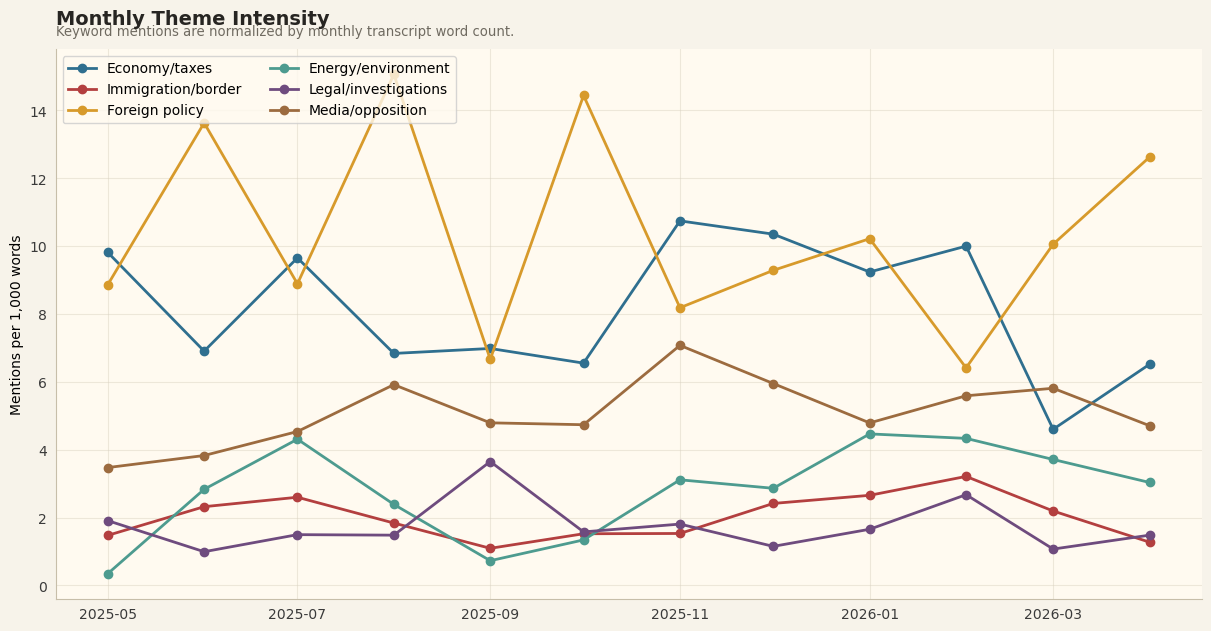

In [9]:
monthly_theme = transcripts_df.dropna(subset=["month"]).groupby("month")[[f"theme_{t}" for t in theme_keywords]].sum()
monthly_words = transcripts_df.dropna(subset=["month"]).groupby("month")["word_count"].sum()
monthly_theme_per_1k = monthly_theme.div(monthly_words, axis=0) * 1000
monthly_theme_per_1k.columns = [c.replace("theme_", "") for c in monthly_theme_per_1k.columns]

fig, ax = plt.subplots(figsize=(12, 6.2), constrained_layout=True)
fig.patch.set_facecolor(cream)
colors = [blue, red, gold, teal, plum, "#9c6b3f"]
for color, col in zip(colors, monthly_theme_per_1k.columns):
    ax.plot(monthly_theme_per_1k.index, monthly_theme_per_1k[col], marker="o", linewidth=2.0, label=col, color=color)
ax.set_ylabel("Mentions per 1,000 words")
polish(ax, "Monthly Theme Intensity", "Keyword mentions are normalized by monthly transcript word count.")
ax.legend(ncol=2, loc="upper left")
save_fig(fig, "monthly_theme_intensity.png")
plt.show()


## Finance-Specific Language

This chart focuses only on market/economic terms that connect naturally to the VIX and S&P 500 analysis.


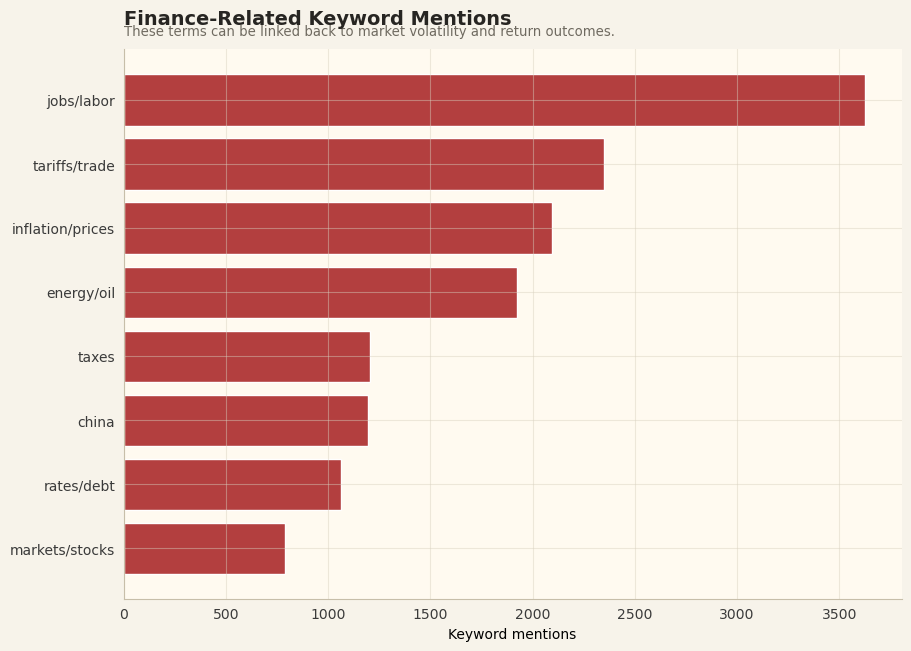

jobs/labor          3624
tariffs/trade       2348
inflation/prices    2097
energy/oil          1923
taxes               1203
china               1194
rates/debt          1063
markets/stocks       790
dtype: int64

In [10]:
finance_keywords = {
    "tariffs/trade": ["tariff", "tariffs", "trade"],
    "taxes": ["tax", "taxes", "taxed"],
    "inflation/prices": ["inflation", "prices", "price", "costs"],
    "jobs/labor": ["jobs", "job", "workers", "wages", "labor"],
    "markets/stocks": ["market", "markets", "stock", "stocks", "wall street"],
    "rates/debt": ["rates", "interest", "debt", "deficit", "treasury"],
    "energy/oil": ["energy", "oil", "gas", "drilling"],
    "china": ["china", "chinese"],
}

for label, keywords in finance_keywords.items():
    transcripts_df[f"finance_{label}"] = transcripts_df["body_lower"].apply(lambda text: count_keywords(text, keywords))

finance_totals = pd.Series({label: transcripts_df[f"finance_{label}"].sum() for label in finance_keywords}).sort_values()

fig, ax = plt.subplots(figsize=(9, 6.4), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.barh(finance_totals.index, finance_totals.values, color=red, edgecolor="white")
ax.set_xlabel("Keyword mentions")
polish(ax, "Finance-Related Keyword Mentions", "These terms can be linked back to market volatility and return outcomes.")
save_fig(fig, "finance_keyword_mentions.png")
plt.show()

finance_totals.sort_values(ascending=False)


## Theme Co-Occurrence

The co-occurrence matrix shows which themes tend to appear in the same transcript.


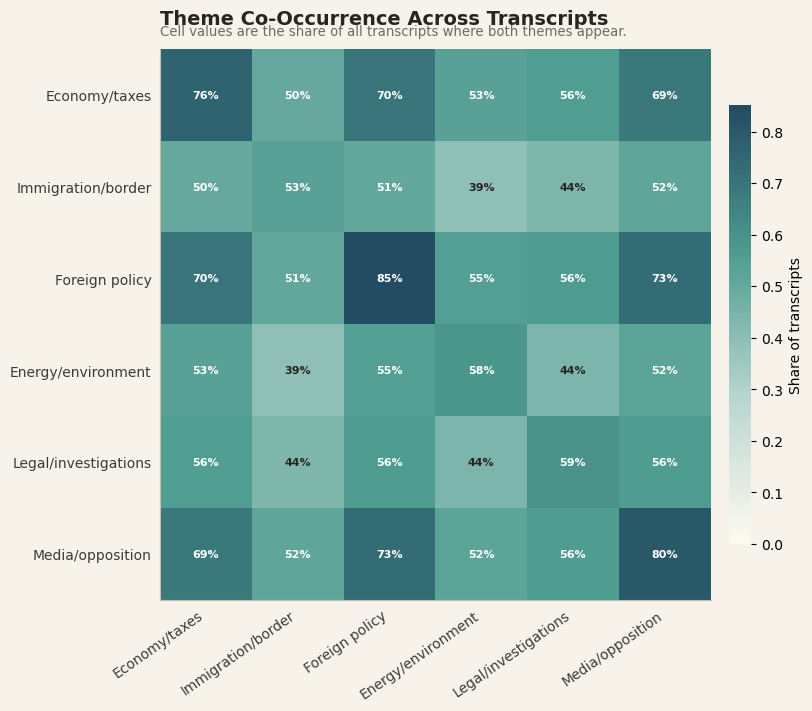

In [11]:
theme_names = list(theme_keywords.keys())
presence = pd.DataFrame({theme: transcripts_df[f"has_{theme}"] for theme in theme_names})
cooccur = pd.DataFrame(index=theme_names, columns=theme_names, dtype=float)
for a in theme_names:
    for b in theme_names:
        cooccur.loc[a, b] = (presence[a] & presence[b]).mean()

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
fig.patch.set_facecolor(cream)
im = ax.imshow(cooccur.values, cmap=blue_cmap, vmin=0, vmax=cooccur.values.max())
ax.set_xticks(range(len(theme_names)), theme_names, rotation=35, ha="right")
ax.set_yticks(range(len(theme_names)), theme_names)
ax.grid(False)
polish(ax, "Theme Co-Occurrence Across Transcripts", "Cell values are the share of all transcripts where both themes appear.")
for i in range(len(theme_names)):
    for j in range(len(theme_names)):
        val = cooccur.iloc[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8, color="white" if val > cooccur.values.max() * 0.55 else ink, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("Share of transcripts")
cbar.outline.set_visible(False)
save_fig(fig, "theme_cooccurrence_heatmap.png")
plt.show()


## Finance Share vs Transcript Length

This scatter plot asks whether longer transcripts are also more finance-heavy, measured as finance keyword mentions per 1,000 words.


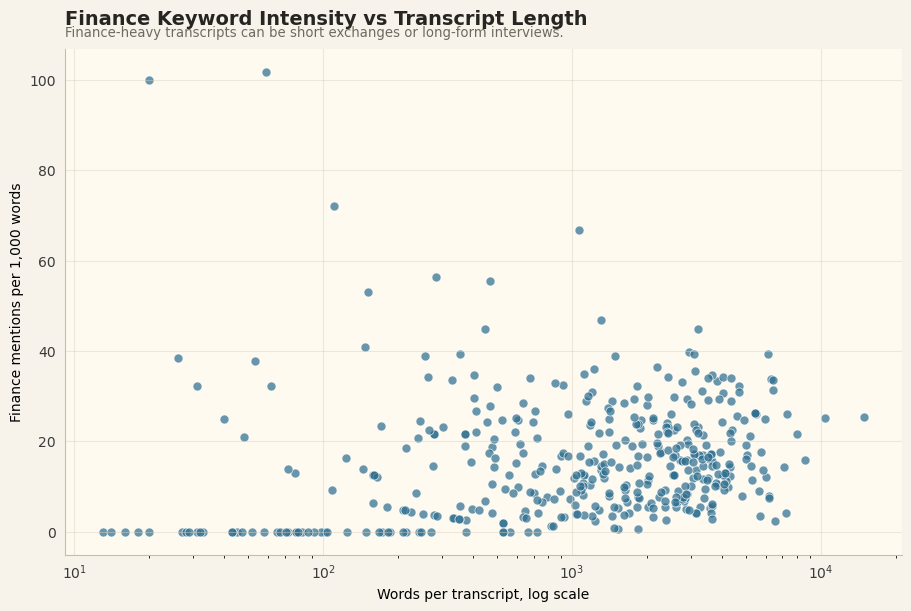

,date,file,word_count,finance_mentions,finance_mentions_per_1k
269,2025-09-30,09302025-0.txt,59,6,101.69
174,2025-06-05,06052025-1.txt,20,2,100.00
390,2025-12-17,12172025-2.txt,111,8,72.07
219,2025-07-24,07242025-1.txt,1065,71,66.67
64,2026-02-19,02192026-0.txt,284,16,56.34
415,NaT,UNKNOWNDATE-2.txt,469,26,55.44
53,2026-02-06,02062026-0.txt,151,8,52.98
388,2025-12-17,12172025-0.txt,1304,61,46.78
396,2025-12-26,12262025-0.txt,445,20,44.94
145,2026-04-16,04162026-1.txt,3194,143,44.77


In [12]:
finance_cols = [f"finance_{label}" for label in finance_keywords]
transcripts_df["finance_mentions"] = transcripts_df[finance_cols].sum(axis=1)
transcripts_df["finance_mentions_per_1k"] = transcripts_df["finance_mentions"] / transcripts_df["word_count"].replace(0, np.nan) * 1000
scatter_df = transcripts_df.dropna(subset=["finance_mentions_per_1k", "word_count"]).copy()

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.scatter(scatter_df["word_count"], scatter_df["finance_mentions_per_1k"], s=42, color=blue, alpha=0.72, edgecolor="white", linewidth=0.6)
ax.set_xscale("log")
ax.set_xlabel("Words per transcript, log scale")
ax.set_ylabel("Finance mentions per 1,000 words")
polish(ax, "Finance Keyword Intensity vs Transcript Length", "Finance-heavy transcripts can be short exchanges or long-form interviews.")
save_fig(fig, "finance_intensity_vs_length.png")
plt.show()

scatter_df.sort_values("finance_mentions_per_1k", ascending=False)[["date", "file", "word_count", "finance_mentions", "finance_mentions_per_1k"]].head(10).round(2)


## Export Aggregate Features

The notebook exports transcript-level aggregate features, but not raw transcript bodies or raw token lists.


In [13]:
export_cols = [
    "file", "title", "date", "body_chars", "word_count", "unique_words", "lexical_diversity",
    "finance_mentions", "finance_mentions_per_1k",
] + [f"theme_{theme}" for theme in theme_keywords] + [f"finance_{label}" for label in finance_keywords]

export_df = transcripts_df[export_cols].copy()
export_df.to_csv(Path("../final_data/transcript_aggregate_features.csv"), index=False)
print("Exported ../final_data/transcript_aggregate_features.csv")
print("Saved figures to", ASSET_PATH)


Exported ../final_data/transcript_aggregate_features.csv
Saved figures to assets/transcript_visualizations


## Takeaway

These visuals make the transcript corpus easier to describe before modeling: how much text exists, when it appears, which terms dominate, which themes co-occur, and how finance-related language varies across events.
